In [10]:
import sys
if "ESP32_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [11]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import tensorflow as tf
import math

    temp   humi   gray  risk
0  24.49  43.25  0.070     0
1  22.59  48.55  0.195     0
2  24.94  42.08  0.203     0
3  27.57  46.92  0.271     1
4  22.30  31.06  0.000     2


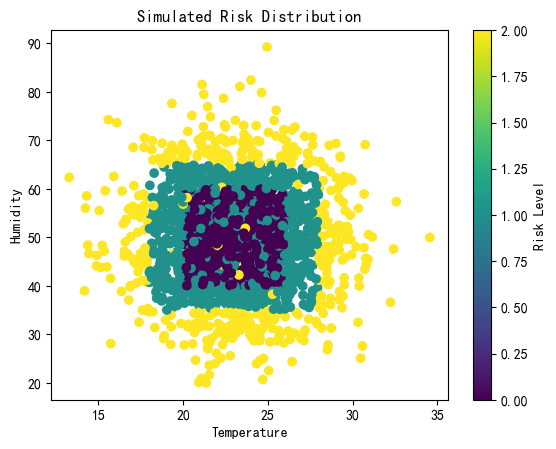

In [ ]:
# ----------------- 1. 构建模拟数据 -----------------
np.random.seed(42)
N = 1000

# 模拟传感器数据
temp = np.random.normal(23, 3, N)  # 温度
humi = np.random.normal(50, 10, N)  # 湿度
gray = np.random.normal(0.2, 0.15, N)  # 光强 (归一化 0~1)

# 限制合理范围
temp = np.clip(temp, 10, 40)
humi = np.clip(humi, 20, 90)
gray = np.clip(gray, 0, 1)

# ----------------- 2. 风险评估函数 -----------------
def evaluate(t, h, g):
    if t < 18 or t > 28 or h < 35 or h > 65 or g > 0.5:
        return 2  # 高风险
    if (18 <= t < 20 or 26 < t <= 28 or
        35 <= h < 40 or 60 < h <= 65 or
        0.3 < g <= 0.5):
        return 1  # 轻度风险
    return 0  # 安全

risk = np.array([evaluate(t, h, g) for t, h, g in zip(temp, humi, gray)])

# ----------------- 3. 构建 DataFrame -----------------
df = pd.DataFrame({
    "temp": temp,
    "humi": humi,
    "gray": gray,
    "risk": risk
})
df = df.round({
    "temp": 2,
    "humi": 2,
    "gray": 3
})
print(df.head())

# 可视化风险分布
plt.scatter(df['temp'], df['humi'], c=df['risk'], cmap='viridis')
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Simulated Risk Distribution")
plt.colorbar(label="Risk Level")
plt.show()

In [13]:
# ----------------- 4. 数据拆分 -----------------
from sklearn.model_selection import train_test_split

X = df[['temp', 'humi', 'gray']].values.astype(np.float32)
y = df['risk'].values.astype(np.float32)  # 单输出回归模型

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# ----------------- 5. 创建神经网络 -----------------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(3,)),  # 三个输入
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)  # 输出风险等级（浮点）
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

d:\conda_envs\ESP32_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ----------------- 6. 模型训练 -----------------
model.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, verbose=2)

Epoch 1/200
40/40 - 1s - 15ms/step - loss: 0.6662 - mae: 0.6803 - val_loss: 0.5812 - val_mae: 0.6381
Epoch 2/200
40/40 - 0s - 2ms/step - loss: 0.5584 - mae: 0.6256 - val_loss: 0.5195 - val_mae: 0.6051
Epoch 3/200
40/40 - 0s - 2ms/step - loss: 0.5099 - mae: 0.6034 - val_loss: 0.4958 - val_mae: 0.6012
Epoch 4/200
40/40 - 0s - 2ms/step - loss: 0.4758 - mae: 0.5826 - val_loss: 0.4699 - val_mae: 0.5874
Epoch 5/200
40/40 - 0s - 2ms/step - loss: 0.4400 - mae: 0.5651 - val_loss: 0.4477 - val_mae: 0.5742
Epoch 6/200
40/40 - 0s - 2ms/step - loss: 0.4155 - mae: 0.5477 - val_loss: 0.4290 - val_mae: 0.5560
Epoch 7/200
40/40 - 0s - 2ms/step - loss: 0.4038 - mae: 0.5383 - val_loss: 0.4240 - val_mae: 0.5540
Epoch 8/200
40/40 - 0s - 2ms/step - loss: 0.3910 - mae: 0.5296 - val_loss: 0.4201 - val_mae: 0.5505
Epoch 9/200
40/40 - 0s - 2ms/step - loss: 0.3843 - mae: 0.5246 - val_loss: 0.4098 - val_mae: 0.5434
Epoch 10/200
40/40 - 0s - 2ms/step - loss: 0.3837 - mae: 0.5247 - val_loss: 0.4050 - val_mae: 0.539

In [16]:
# ----------------- 7. 保存 TFLite FP32 模型 -----------------
import pathlib

# 假设 model 已经训练完成
# model.fit(...)

# ----------------- 1. 直接转换 Keras 模型 -----------------
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = []               # 不做任何优化
converter.target_spec.supported_types = [tf.float32]  # 使用 ESP32

tflite_model = converter.convert()

# ----------------- 2. 保存 TFLite 文件 -----------------
tflite_model_file = pathlib.Path('model.tflite')
tflite_model_file.write_bytes(tflite_model)
print("FP32 TFLite 模型已保存为:", tflite_model_file)

# ----------------- 3. 生成 C++ 数组 -----------------
cc_file_path = pathlib.Path("model.cc")
with open(cc_file_path, "w", encoding="utf-8") as f:
    f.write('#include "model.h"\n\n')
    f.write("const unsigned char g_model[] = {\n")
    for i, b in enumerate(tflite_model):
        if i % 12 == 0:
            f.write("    ")
        f.write(f"0x{b:02x}, ")
        if (i + 1) % 12 == 0:
            f.write("\n")
    f.write("\n};\n\n")
    f.write(f"const int g_model_len = {len(tflite_model)};\n")

print(f"干净的 model.cc 已生成，长度 {len(tflite_model)} 字节")

INFO:tensorflow:Assets written to: C:\Users\lxl\AppData\Local\Temp\tmpnfj2m09y\assets


INFO:tensorflow:Assets written to: C:\Users\lxl\AppData\Local\Temp\tmpnfj2m09y\assets


Saved artifact at 'C:\Users\lxl\AppData\Local\Temp\tmpnfj2m09y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1542654055184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1542654055376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1542654066512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1542654058640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1542654053840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1542654058256: TensorSpec(shape=(), dtype=tf.resource, name=None)
FP32 TFLite 模型已保存为: model.tflite
干净的 model.cc 已生成，长度 3324 字节
